In [2]:

import cv2, os, random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import duckdb
from pathlib import Path
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42

ModuleNotFoundError: No module named 'cv2'

### Connexion à la DB / Import des Data


In [1]:
# Store database at project root
DB_NAME = Path("/home/c-enjalbert/Documents/Github/MSPR/bloc_2/amazing/amazing.duckdb") 
# Go up one level from current directory to get to project root
data_folder = Path("..") / "data"
# For absolute certainty, you could use the absolute path
# data_folder = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/data")
con = duckdb.connect(str(DB_NAME))

NameError: name 'Path' is not defined

### Import de la table DuckDB

In [ ]:
DB_NAME = "amazing.duckdb"
TABLE_EVENTS = "user_events"
TABLE_SEGMENTS = "user_segments"
SAMPLE_USER_PERCENT = 0.2
BATCH_SIZE = 1000 

In [ ]:
# 5. Alternative way to show all tables
print("List of all tables using DuckDB's connections.tables():")
con.sql("SHOW TABLES").show()

List of all tables using DuckDB's connections.tables():
┌──────────────────────┐
│         name         │
│       varchar        │
├──────────────────────┤
│ all_events           │
│ loaded_files         │
│ user_events          │
│ user_segments_kmeans │
└──────────────────────┘



In [ ]:
# Examine the all_events table
print(f"First 10 rows of {TABLE_EVENTS} table:")
user_events = con.sql(f"""
    SELECT * FROM {TABLE_EVENTS}
""")
user_events.show()
user_events_df = user_events.df()


First 10 rows of user_events table:
┌───────────┬──────────────┬─────────────┬─────────────────┬─────────────────────────┬─────────────┬───────────────────┬─────────────────────┬──────────────────────┬──────────────────────┬───────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│  user_id  │ total_events │ total_views │ total_purchases │ avg_time_between_events │ total_spent │    avg_basket     │   last_event_time   │   conversion_rate    │    purchase_ratio    │ days_since_last_event │                                                                                                      category_embedding                                                                                                       │
│  varchar  │    int64     │   double    │     double      │         double          │   d

In [ ]:
x_b, y_b = con.

## 1. Tests de Robustesse :

| Champ              | Contenu attendu                         |
|--------------------|------------------------------------------|
| ID du test         | TST-IA-001                               |
| Objectif du test   | Vérifier la robustesse au bruit          |
| Description        | Ajouter du bruit à l'entrée image        |
| Données utilisées  | Dataset CIFAR10 Bruité              |
| Méthode            | Injection de bruit aléatoire (Gaussian)  |
| Résultat attendu   | Précision ≥ 82 %                         |
| Résultat obtenu    | 2.5 % - 5% DE BRuit SIGMA / FLOU = 1,5 KERNEL SIZE /  2° d'angle de                       |rotation                |
| Statut             |     NOT READY FOR PROD TO BE                              |
| Commentaire             |     Trop sensible au bruit, au flou et aux rotations de l'image                              |


In [ ]:
x_val_list, y_val_list = [], []
for x_b, y_b in ds_val:
    x_val_list.append(x_b.numpy())
    y_val_list.append(y_b.numpy())

x_val = np.concatenate(x_val_list, axis=0)
y_val = np.concatenate(y_val_list, axis=0).reshape(-1)

print("x_val:", x_val.shape, "y_val:", y_val.shape)

# Sous-ensemble de test robustesse
N_SUB = 1000
idx = np.random.choice(len(x_val), N_SUB, replace=False)
x_sub = x_val[idx]
y_sub = y_val[idx]

x_val: (5000, 32, 32, 3) y_val: (5000,)


In [ ]:
def gaussian_noise(images, sigma):
    """Ajoute un bruit gaussien d'écart-type sigma."""
    noise = np.random.normal(0, sigma, images.shape)
    return np.clip(images + noise, 0, 1)

def gaussian_blur(images, ksize):
    """Flou gaussien avec kernel ksize (impair). ksize=1 => pas de flou."""
    if ksize == 1:
        return images.copy()
    out = []
    for img in images:
        b = cv2.GaussianBlur((img*255).astype(np.uint8), (ksize, ksize), 0)
        out.append(b.astype(np.float32)/255.0)
    return np.array(out)

def rotate_images(images, angle):
    """Rotate a batch of images  by `angle` degrees using PIL"""
    out = []
    for img in images:
        im = Image.fromarray((img * 255).astype(np.uint8))
        imr = im.rotate(angle, resample=Image.BILINEAR, expand=False, fillcolor=(0,0,0))
        out.append(np.array(imr).astype(np.float32) / 255.0)
    return np.stack(out, axis=0)

def eval_np(model, x, y):
    prob = model.predict(x, verbose=0)
    pred = np.argmax(prob, axis=1)
    acc = accuracy_score(y, pred)
    f1  = f1_score(y, pred, average="macro")
    return acc, f1

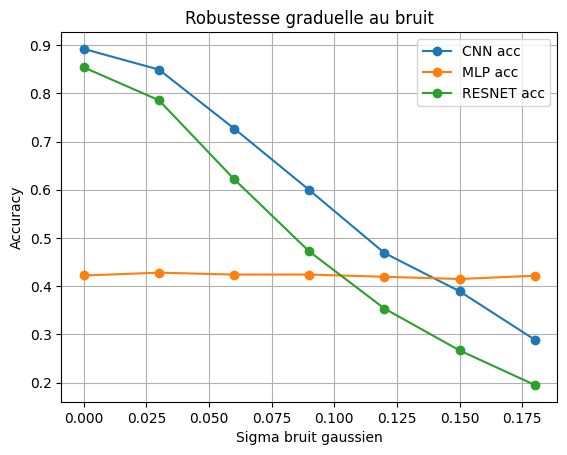

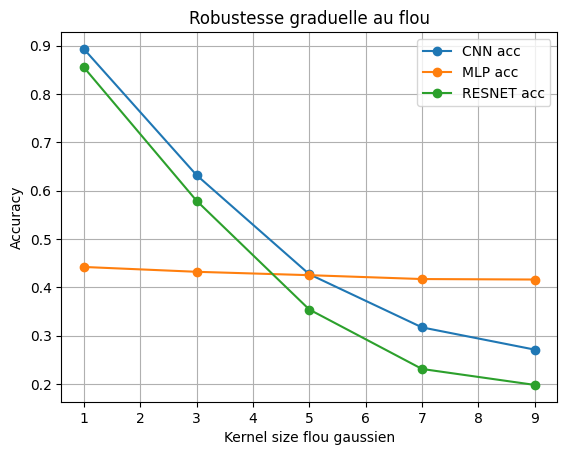

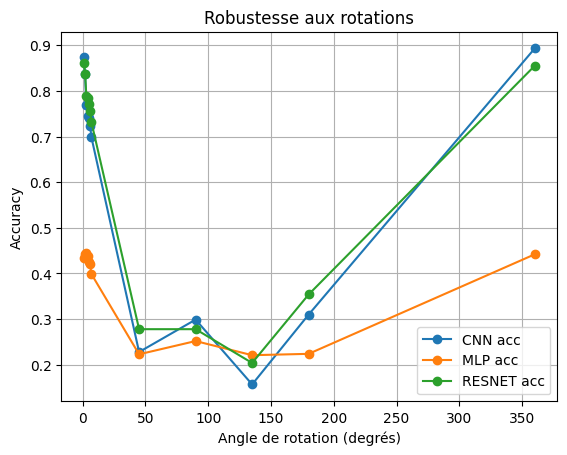


=== Résumé Bruit ===
sigma=0.00 | CNN acc=0.893 | MLP acc=0.442 | RESNET acc=0.855
sigma=0.03 | CNN acc=0.850 | MLP acc=0.448 | RESNET acc=0.791
sigma=0.06 | CNN acc=0.724 | MLP acc=0.445 | RESNET acc=0.630
sigma=0.09 | CNN acc=0.594 | MLP acc=0.443 | RESNET acc=0.505
sigma=0.12 | CNN acc=0.469 | MLP acc=0.439 | RESNET acc=0.394
sigma=0.15 | CNN acc=0.399 | MLP acc=0.434 | RESNET acc=0.316
sigma=0.18 | CNN acc=0.318 | MLP acc=0.439 | RESNET acc=0.257

=== Résumé Flou ===
ksize=1 | CNN acc=0.893 | MLP acc=0.442 | RESNET acc=0.855
ksize=3 | CNN acc=0.632 | MLP acc=0.432 | RESNET acc=0.579
ksize=5 | CNN acc=0.427 | MLP acc=0.425 | RESNET acc=0.354
ksize=7 | CNN acc=0.317 | MLP acc=0.417 | RESNET acc=0.231
ksize=9 | CNN acc=0.271 | MLP acc=0.416 | RESNET acc=0.198

=== Résumé Rotations ===
angle=1° | CNN acc=0.875 | MLP acc=0.435 | RESNET acc=0.860
angle=2° | CNN acc=0.836 | MLP acc=0.443 | RESNET acc=0.838
angle=3° | CNN acc=0.768 | MLP acc=0.444 | RESNET acc=0.789
angle=4° | CNN acc=0.7

In [ ]:

# Test de Robustesse BRUIT

noise_levels = [0.0, 0.03, 0.06, 0.09, 0.12, 0.15, 0.18]

cnn_acc_noise, mlp_acc_noise, resnet_acc_noise = [], [], []
cnn_f1_noise,  mlp_f1_noise, resnet_f1_noise  = [], [], []

for s in noise_levels:
    x_pert = gaussian_noise(x_sub, sigma=s)
    acc_cnn, f1_cnn = eval_np(cnn, x_pert, y_sub)
    acc_mlp, f1_mlp = eval_np(mlp, x_pert, y_sub)
    acc_resnet, f1_resnet = eval_np(resnet, x_pert, y_sub)
    cnn_acc_noise.append(acc_cnn); cnn_f1_noise.append(f1_cnn)
    mlp_acc_noise.append(acc_mlp); mlp_f1_noise.append(f1_mlp)
    resnet_acc_noise.append(acc_resnet); resnet_f1_noise.append(f1_resnet)


plt.plot(noise_levels, cnn_f1_noise, marker="o", label="CNN acc")
plt.plot(noise_levels, mlp_f1_noise, marker="o", label="MLP acc")
plt.plot(noise_levels, resnet_f1_noise, marker="o", label="RESNET acc")
plt.xlabel("Sigma bruit gaussien")
plt.ylabel("Accuracy")
plt.title("Robustesse graduelle au bruit")
plt.legend()
plt.grid(True)
plt.show()

# Test de Robustesse FLOU

blur_levels = [1, 3, 5, 7, 9]

cnn_acc_blur, mlp_acc_blur, resnet_acc_blur = [], [], []
cnn_f1_blur,  mlp_f1_blur, resnet_f1_blur  = [], [], []

for k in blur_levels:
    x_pert = gaussian_blur(x_sub, ksize=k)
    acc_cnn, f1_cnn = eval_np(cnn, x_pert, y_sub)
    acc_mlp, f1_mlp = eval_np(mlp, x_pert, y_sub)
    acc_resnet, f1_resnet = eval_np(resnet, x_pert, y_sub)
    cnn_acc_blur.append(acc_cnn); cnn_f1_blur.append(f1_cnn)
    mlp_acc_blur.append(acc_mlp); mlp_f1_blur.append(f1_mlp)
    resnet_acc_blur.append(acc_resnet); resnet_f1_blur.append(f1_resnet)

plt.plot(blur_levels, cnn_acc_blur, marker="o", label="CNN acc")
plt.plot(blur_levels, mlp_acc_blur, marker="o", label="MLP acc")
plt.plot(blur_levels, resnet_acc_blur, marker="o", label="RESNET acc")
plt.xlabel("Kernel size flou gaussien")
plt.ylabel("Accuracy")
plt.title("Robustesse graduelle au flou")
plt.legend()
plt.grid(True)
plt.show()

# Test de Robustesse ROTATIONS

rot_levels = [1,2,3,4,5,6,7,45, 90, 135, 180, 360]

cnn_acc_rot, mlp_acc_rot, resnet_acc_rot = [], [], []
cnn_f1_rot,  mlp_f1_rot, resnet_f1_rot  = [], [], []

for a in rot_levels:
    if a == 0:
        x_pert = x_sub
    else:
        x_pert = rotate_images(x_sub, a)

    acc_cnn, f1_cnn = eval_np(cnn, x_pert, y_sub)
    acc_mlp, f1_mlp = eval_np(mlp, x_pert, y_sub)
    acc_resnet, f1_resnet = eval_np(resnet, x_pert, y_sub)

    cnn_acc_rot.append(acc_cnn); cnn_f1_rot.append(f1_cnn)
    mlp_acc_rot.append(acc_mlp); mlp_f1_rot.append(f1_mlp)
    resnet_acc_rot.append(acc_resnet); resnet_f1_rot.append(f1_resnet)

plt.plot(rot_levels, cnn_acc_rot, marker="o", label="CNN acc")
plt.plot(rot_levels, mlp_acc_rot, marker="o", label="MLP acc")
plt.plot(rot_levels, resnet_acc_rot, marker="o", label="RESNET acc")
plt.xlabel("Angle de rotation (degrés)")
plt.ylabel("Accuracy")
plt.title("Robustesse aux rotations")
plt.legend()
plt.grid(True)
plt.show()

print("\n=== Résumé Bruit ===")
for s, a1, a2, a3 in zip(noise_levels, cnn_acc_noise, mlp_acc_noise, resnet_acc_noise):
    print(f"sigma={s:.2f} | CNN acc={a1:.3f} | MLP acc={a2:.3f} | RESNET acc={a3:.3f}")

print("\n=== Résumé Flou ===")
for k, a1, a2, a3 in zip(blur_levels, cnn_acc_blur, mlp_acc_blur, resnet_acc_blur):
    print(f"ksize={k} | CNN acc={a1:.3f} | MLP acc={a2:.3f} | RESNET acc={a3:.3f}")

print("\n=== Résumé Rotations ===")
for a, a1, a2, a3 in zip(rot_levels, cnn_acc_rot, mlp_acc_rot, resnet_acc_rot):
    print(f"angle={a}° | CNN acc={a1:.3f} | MLP acc={a2:.3f} | RESNET acc={a3:.3f}")

## 2. Prise en compte du Biais : 

pas de Biais

## 3. Tests :

| Champ              | Contenu attendu                         |
|--------------------|------------------------------------------|
| ID du test         | TST-IA-002                               |
| Objectif du test   | Identifier un potentiel "mode" pour les fausses prédictions           |
| Description        | Observer un désquilibre dans les fausses classes prédites     |
| Données utilisées  | Dataset CIFAR10               |
| Méthode            | Comparaison des indices de confiances des classes prédites  |
| Résultat attendu   | Un haut F1 Score pour chaque classe (>80)                        |
| Résultat obtenu    | Les classes ont des F1 Scores supérieurs à 0,80 cependant *deer*, *dog* et *bird* sont légèrement en-dessous, nous pourrions faire une analyse approfondie pour ces classes                   |
| Statut             | OK                                  |


3 classes les plus faibles
dog | F1_CNN=0.739  F1_MLP=0.211 F1_RESNET=0.826
bird | F1_CNN=0.790  F1_MLP=0.119 F1_RESNET=0.859
cat | F1_CNN=0.825  F1_MLP=0.294 F1_RESNET=0.796


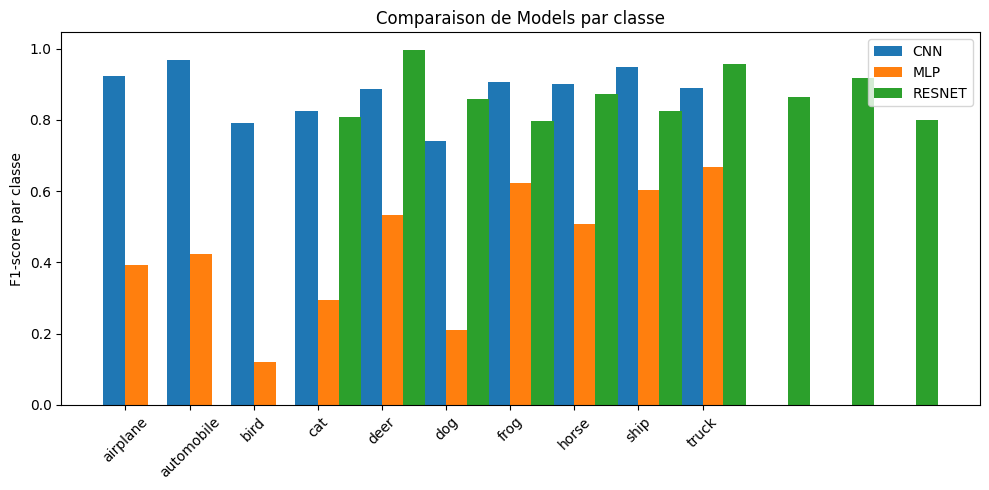


--- Classe faible CNN : dog ---
Confondue avec cat : 79 fois
Confondue avec horse : 28 fois
Confondue avec deer : 18 fois
Confondue avec bird : 7 fois

--- Classe faible CNN : bird ---
Confondue avec deer : 25 fois
Confondue avec airplane : 20 fois
Confondue avec frog : 16 fois
Confondue avec cat : 14 fois

--- Classe faible CNN : cat ---
Confondue avec dog : 40 fois
Confondue avec bird : 14 fois
Confondue avec frog : 14 fois
Confondue avec deer : 12 fois

--- Classe faible MLP : dog ---
Confondue avec cat : 116 fois
Confondue avec frog : 104 fois
Confondue avec deer : 80 fois
Confondue avec horse : 51 fois

--- Classe faible MLP : bird ---
Confondue avec deer : 160 fois
Confondue avec frog : 93 fois
Confondue avec cat : 32 fois
Confondue avec horse : 31 fois

--- Classe faible MLP : cat ---
Confondue avec frog : 133 fois
Confondue avec deer : 62 fois
Confondue avec dog : 39 fois
Confondue avec horse : 30 fois

--- Classe faible RESNET : dog ---
Confondue avec cat : 52 fois
Confondue 

In [ ]:
x_val_list, y_val_list = [], []
for xb, yb in ds_val:
    x_val_list.append(xb.numpy())
    y_val_list.append(yb.numpy())

x_val = np.concatenate(x_val_list, axis=0)
y_val = np.concatenate(y_val_list, axis=0).reshape(-1)

# Prédictions CNN & MLP & Resnet
prob_cnn = cnn.predict(x_val, verbose=0)
pred_cnn = np.argmax(prob_cnn, axis=1)

prob_mlp = mlp.predict(x_val, verbose=0)
pred_mlp = np.argmax(prob_mlp, axis=1)

prob_resnet = resnet.predict(x_val, verbose=0)
pred_resnet = np.argmax(prob_resnet, axis=1)

# F1 par classe
classes = list(le.classes_)
f1_cnn, f1_mlp, f1_resnet  = [], [], []

for i in range(len(classes)):
    mask = (y_val == i)
    acc_cnn = accuracy_score(y_val[mask], pred_cnn[mask])
    acc_mlp = accuracy_score(y_val[mask], pred_mlp[mask])
    acc_resnet = accuracy_score(y_val[mask], pred_resnet[mask])
    f1_cnn.append(acc_cnn)
    f1_mlp.append(acc_mlp)
    f1_resnet.append(acc_resnet)

f1_cnn = np.array(f1_cnn)
f1_mlp = np.array(f1_mlp)
f1_resnet = np.array(f1_resnet)

# Affichage des 3 classes les plus faibles
idx_worst = np.argsort(f1_cnn)[:3]
print("3 classes les plus faibles")
for i in idx_worst:
    print(f"{classes[i]} | F1_CNN={f1_cnn[i]:.3f}  F1_MLP={f1_mlp[i]:.3f} F1_RESNET={f1_resnet[i]:.3f}")

# Barplot F1 par classe
x = np.arange(len(3))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar(x - width/2, f1_cnn, width, label="CNN")
plt.bar(x + width/2, f1_mlp, width, label="MLP")
plt.bar(x + width*2, f1_resnet, width, label="RESNET")
plt.xticks(x, classes, rotation=45)
plt.ylabel("F1-score par classe")
plt.title("Comparaison de Models par classe")
plt.legend()
plt.tight_layout()
plt.show()

# Confusions principales pour les classes faibles (CNN)
cm_cnn = confusion_matrix(y_val, pred_cnn)

for i in idx_worst:
    print(f"\n--- Classe faible CNN : {classes[i]} ---")
    conf = np.argsort(cm_cnn[i])[::-1][:5]
    for j in conf:
        if j == i:
            continue
        print(f"Confondue avec {classes[j]} : {cm_cnn[i, j]} fois")

# Confusions principales pour les classes faibles (MLP)
cm_cnn = confusion_matrix(y_val, pred_mlp)

for i in idx_worst:
    print(f"\n--- Classe faible MLP : {classes[i]} ---")
    conf = np.argsort(cm_cnn[i])[::-1][:5]
    for j in conf:
        if j == i:
            continue
        print(f"Confondue avec {classes[j]} : {cm_cnn[i, j]} fois")
        
# Confusions principales pour les classes faibles (RESNET)
cm_cnn = confusion_matrix(y_val, pred_resnet)

for i in idx_worst:
    print(f"\n--- Classe faible RESNET : {classes[i]} ---")
    conf = np.argsort(cm_cnn[i])[::-1][:5]
    for j in conf:
        if j == i:
            continue
        print(f"Confondue avec {classes[j]} : {cm_cnn[i, j]} fois")

## 3. Tests aux Limites (Corner Cases) :

| Champ              | Contenu attendu                         |
|--------------------|------------------------------------------|
| ID du test         | TST-IA-003                               |
| Objectif du test   | Identifier un potentiel "mode" pour les fausses prédictions           |
| Description        | Observations du taux de confiance multi-classe pour les fausses prédictions       |
| Données utilisées  | Dataset CIFAR10               |
| Méthode            | Comparison des delta entre les différents indices de confiance entre les classes prédites  |
| Résultat attendu   | Fausses prédictions du modèle pour une classe prédite assimilées à une autre classe spécifique visuellement proche |
| Résultat obtenu    |  Peu de différence entre l'indice de confiance pour la bonne classe et la classe prédite : Lorsque le modèel hésite, la plupart du temps une des deux classes est la bonne.                   |
| Statut             | OK                                  |


In [ ]:
def find_corner_cases_by_margin(model, x, topk=12):
    probs = model.predict(x, verbose=0)
    sorted_probs = np.sort(probs, axis=1)
    margins = sorted_probs[:,-1] - sorted_probs[:,-2]
    idx = np.argsort(margins)[:topk]
    return idx, probs[idx], margins[idx]

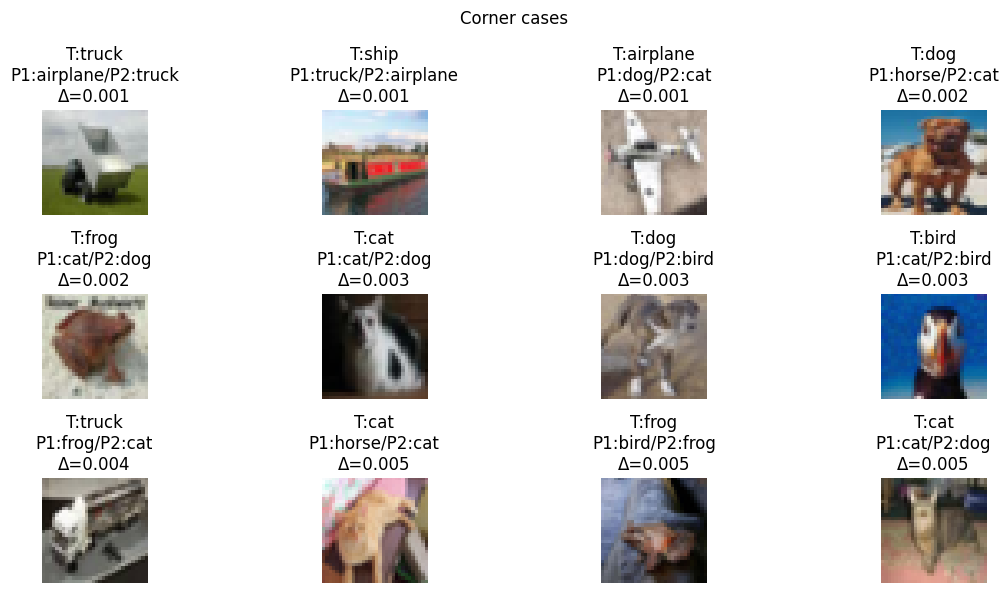

Analyse corner cases (CNN)
Image 3992 | True=truck     | P1=airplane  (0.42) | P2=truck     (0.42) | Δ=0.001
Image 2268 | True=ship      | P1=truck     (0.34) | P2=airplane  (0.34) | Δ=0.001
Image 3418 | True=airplane  | P1=dog       (0.36) | P2=cat       (0.36) | Δ=0.001
Image 1216 | True=dog       | P1=horse     (0.33) | P2=cat       (0.33) | Δ=0.002
Image 1606 | True=frog      | P1=cat       (0.26) | P2=dog       (0.26) | Δ=0.002
Image 4350 | True=cat       | P1=cat       (0.49) | P2=dog       (0.49) | Δ=0.003
Image 2757 | True=dog       | P1=dog       (0.26) | P2=bird      (0.25) | Δ=0.003
Image 1287 | True=bird      | P1=cat       (0.35) | P2=bird      (0.35) | Δ=0.003
Image 4805 | True=truck     | P1=frog      (0.37) | P2=cat       (0.37) | Δ=0.004
Image 2260 | True=cat       | P1=horse     (0.33) | P2=cat       (0.33) | Δ=0.005
Image 2429 | True=frog      | P1=bird      (0.24) | P2=frog      (0.24) | Δ=0.005
Image 2230 | True=cat       | P1=cat       (0.35) | P2=dog       (0.34)

In [ ]:
corner_idx, corner_probs, corner_margins = find_corner_cases_by_margin(cnn, x_val, topk=12)

plt.figure(figsize=(12,6))
for i, k in enumerate(corner_idx):
    plt.subplot(3,4,i+1)
    plt.imshow(x_val[k])
    plt.axis("off")
    true_c = classes[y_val[k]]
    top1 = np.argmax(corner_probs[i])
    top2 = np.argsort(corner_probs[i])[-2]
    pred1 = classes[top1]
    pred2 = classes[top2]
    plt.title(f"T:{true_c}\nP1:{pred1}/P2:{pred2}\nΔ={corner_margins[i]:.3f}")
plt.suptitle("Corner cases")
plt.tight_layout()
plt.show()

print("Analyse corner cases (CNN)")
for i, k in enumerate(corner_idx):
    true_c = classes[y_val[k]]
    top1 = np.argmax(corner_probs[i])
    top2 = np.argsort(corner_probs[i])[-2]
    pred1 = classes[top1]
    pred2 = classes[top2]
    print(f"Image {k:4d} | True={true_c:9s} | P1={pred1:9s} ({corner_probs[i][top1]:.2f}) "
          f"| P2={pred2:9s} ({corner_probs[i][top2]:.2f}) | Δ={corner_margins[i]:.3f}")